### Configuración GPU e Importaciones

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sysconfig import get_paths
import ctypes
import os

site_packages = Path(get_paths()['purelib'])
cuda_lib_dirs = [
    site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
    site_packages / 'nvidia' / 'cuda_nvrtc' / 'lib',
    site_packages / 'nvidia' / 'cublas' / 'lib',
    site_packages / 'nvidia' / 'cufft' / 'lib',
    site_packages / 'nvidia' / 'curand' / 'lib',
    site_packages / 'nvidia' / 'cusolver' / 'lib',
    site_packages / 'nvidia' / 'cusparse' / 'lib',
    site_packages / 'nvidia' / 'cudnn' / 'lib',
    site_packages / 'nvidia' / 'cuda_cupti' / 'lib',
    site_packages / 'nvidia' / 'nccl' / 'lib',
    site_packages / 'nvidia' / 'nvjitlink' / 'lib',
]

loaded_cuda_libs = 0
for lib_dir in cuda_lib_dirs:
    if lib_dir.exists():
        for lib_path in sorted(lib_dir.glob('*.so*')):
            ctypes.CDLL(str(lib_path), mode=ctypes.RTLD_GLOBAL)
            loaded_cuda_libs += 1

existing_ld = os.environ.get('LD_LIBRARY_PATH', '')
cuda_ld_paths = [str(path) for path in cuda_lib_dirs if path.exists()]
if existing_ld:
    cuda_ld_paths.append(existing_ld)
os.environ['LD_LIBRARY_PATH'] = ':'.join(cuda_ld_paths)
print(f'Librerías CUDA cargadas: {loaded_cuda_libs}')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print('TensorFlow:', tf.__version__)
print('GPUs detectadas:', gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Crecimiento de memoria habilitado.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1783732077.578679  452006 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Librerías CUDA cargadas: 31
TensorFlow: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Crecimiento de memoria habilitado.


### Carga y Preprocesamiento de Datos

In [2]:
# Cargar dataset
print("Cargando dataset...")
df = pd.read_csv('../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Eliminar ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} características")

# Separar variables
X = df.drop('default', axis=1)
y = df['default']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Distribución clases - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

Cargando dataset...
Dataset cargado: 30000 registros, 24 características
Train: (24000, 23), Test: (6000, 23)
Distribución clases - Train: [18691  5309], Test: [4673 1327]


### Implementación de Grey Wolf Optimizer (GWO)

In [3]:
class GreyWolfOptimizerImproved:
    """
    GWO Mejorado para optimización de hiperparámetros de MLP
    """
    def __init__(self, n_wolves=20, max_iter=30, dim=4):
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.dim = dim
        
        # Inicializar posiciones con mejor distribución
        self.positions = np.zeros((n_wolves, dim))
        for i in range(n_wolves):
            self.positions[i, 0] = np.random.uniform(0.001, 0.01)    # learning_rate
            self.positions[i, 1] = np.random.uniform(0.2, 0.5)       # dropout_rate
            self.positions[i, 2] = np.random.choice([16, 32, 64, 128])  # neurons1 (discreto)
            self.positions[i, 3] = np.random.choice([8, 16, 32, 64])    # neurons2 (discreto)
        
        self.fitness = np.zeros(n_wolves)
        
        self.alpha_pos = np.zeros(dim)
        self.alpha_score = float('inf')
        self.beta_pos = np.zeros(dim)
        self.beta_score = float('inf')
        self.delta_pos = np.zeros(dim)
        self.delta_score = float('inf')
        
        self.history = []
        
    def create_mlp(self, params, input_dim):
        """Crear MLP con hiperparámetros dados"""
        lr = params[0]
        dropout = params[1]
        n1 = int(params[2])
        n2 = int(params[3])
        
        model = Sequential([
            Dense(n1, activation='relu', input_dim=input_dim),
            BatchNormalization(),
            Dropout(dropout),
            Dense(n2, activation='relu'),
            BatchNormalization(),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        
        return model
    
    def evaluate_fitness(self, params, X_train, y_train, X_val, y_val):
        """Evaluar fitness usando AUC en lugar de loss"""
        try:
            model = self.create_mlp(params, X_train.shape[1])
            
            # Entrenar con más épocas y EarlyStopping
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=15,  # ✅ Aumentado de 5 a 15 épocas
                batch_size=256,
                verbose=0,
                callbacks=[
                    EarlyStopping(monitor='val_auc', mode='max', 
                                patience=3, restore_best_weights=True)
                ]
            )
            
            # ✅ Usar AUC en lugar de loss (mejor para datos desbalanceados)
            val_auc = max(history.history['val_auc'])
            
            # ✅ Fitness = 1 - AUC (minimizar)
            fitness = 1 - val_auc
            return fitness
            
        except Exception as e:
            print(f"Error en evaluación: {e}")
            return float('inf')
    
    def optimize(self, X_train, y_train, X_val, y_val):
        """Ejecutar optimización GWO mejorada"""
        print(f"\n🐺 Iniciando GWO Mejorado: {self.n_wolves} lobos, {self.max_iter} iteraciones")
        print(f"Espacio de búsqueda: LR[0.001-0.01], Dropout[0.2-0.5], N1[16,32,64,128], N2[8,16,32,64]\n")
        
        for iteration in range(self.max_iter):
            # ✅ Parámetro a con decrecimiento no lineal (mejor exploración)
            a = 2 * (1 - (iteration / self.max_iter) ** 2)
            
            # Evaluar toda la manada
            for i in range(self.n_wolves):
                self.fitness[i] = self.evaluate_fitness(
                    self.positions[i], X_train, y_train, X_val, y_val
                )
            
            # Actualizar alpha, beta, delta
            for i in range(self.n_wolves):
                if self.fitness[i] < self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.alpha_score
                    self.beta_pos = self.alpha_pos.copy()
                    self.alpha_score = self.fitness[i]
                    self.alpha_pos = self.positions[i].copy()
                elif self.fitness[i] < self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.fitness[i]
                    self.beta_pos = self.positions[i].copy()
                elif self.fitness[i] < self.delta_score:
                    self.delta_score = self.fitness[i]
                    self.delta_pos = self.positions[i].copy()
            
            # Guardar historial
            if iteration % 5 == 0:
                self.history.append({
                    'iteration': iteration,
                    'alpha_score': self.alpha_score,
                    'alpha_pos': self.alpha_pos.copy()
                })
                print(f"Iter {iteration:3d} | Alpha AUC: {1-self.alpha_score:.4f} | "
                      f"LR: {self.alpha_pos[0]:.5f}, DO: {self.alpha_pos[1]:.2f}, "
                      f"N1: {int(self.alpha_pos[2])}, N2: {int(self.alpha_pos[3])}")
            
            # ✅ Actualizar posiciones con mejor exploración
            for i in range(self.n_wolves):
                for j in range(self.dim):
                    r1, r2 = np.random.random(), np.random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta
                    
                    self.positions[i, j] = (X1 + X2 + X3) / 3
            
            # ✅ Mantener límites con valores discretos para neuronas
            self.positions[:, 0] = np.clip(self.positions[:, 0], 0.001, 0.01)
            self.positions[:, 1] = np.clip(self.positions[:, 1], 0.2, 0.5)
            self.positions[:, 2] = np.clip(self.positions[:, 2], 16, 128)
            self.positions[:, 3] = np.clip(self.positions[:, 3], 8, 64)
        
        print(f"\n✅ Optimización completada!")
        print(f"Mejor AUC: {1-self.alpha_score:.4f}")
        print(f"Mejor configuración: LR={self.alpha_pos[0]:.5f}, Dropout={self.alpha_pos[1]:.2f}, "
              f"N1={int(self.alpha_pos[2])}, N2={int(self.alpha_pos[3])}\n")
        
        return self.alpha_pos, self.alpha_score

### Ejecutar Optimización GWO

In [ ]:
# Dividir train en train/val para GWO
X_train_gwo, X_val, y_train_gwo, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Datos para GWO - Train: {X_train_gwo.shape}, Val: {X_val.shape}")

# Inicializar y ejecutar GWO
gwo = GreyWolfOptimizerImproved(
    n_wolves=20,      # Tamaño manada (ajustar según recursos)
    max_iter=30,      # Iteraciones (ajustar según tiempo disponible)
    dim=4             # [learning_rate, dropout, neurons1, neurons2]
)

best_params, best_fitness = gwo.optimize(
    X_train_gwo, y_train_gwo, X_val, y_val
)

# Guardar mejores parámetros
best_lr = best_params[0]
best_dropout = best_params[1]
best_n1 = int(best_params[2])
best_n2 = int(best_params[3])

print("\n" + "="*60)
print(" RESULTADOS GWO - MEJORES HIPERPARÁMETROS")
print("="*60)
print(f"Learning Rate:  {best_lr:.6f}")
print(f"Dropout Rate:   {best_dropout:.3f}")
print(f"Neuronas Capa1: {best_n1}")
print(f"Neuronas Capa2: {best_n2}")
print(f"Val Loss:       {best_fitness:.4f}")
print("="*60)

Datos para GWO - Train: (19200, 23), Val: (4800, 23)

🐺 Iniciando GWO Mejorado: 20 lobos, 30 iteraciones
Espacio de búsqueda: LR[0.001-0.01], Dropout[0.2-0.5], N1[16,32,64,128], N2[8,16,32,64]



I0000 00:00:1783732146.550684  452006 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2128 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1783732150.269856  453308 service.cc:153] XLA service 0x7f95280373f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783732150.269879  453308 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783732150.341254  453308 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783732150.841816  453308 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783732150.957142  453308 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2495__.25
I0000 00:00:1783732153.178633  453446 subprocess_c

Iter   0 | Alpha AUC: 0.7723 | LR: 0.00984, DO: 0.28, N1: 32, N2: 16


I0000 00:00:1783732350.863834  453305 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212866__.25
I0000 00:00:1783732360.880356  453306 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_223110__.25
I0000 00:00:1783732371.038253  453305 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231517__.25
I0000 00:00:1783732383.192579  453307 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_243614__.25
I0000 00:00:1783732395.165241  453307 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_255655__.25
I0000 00:00:1783732395.285863  453307 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783732396.783875  453307 dot_search_space.cc:240] All configs were fil

Iter   5 | Alpha AUC: 0.7764 | LR: 0.00541, DO: 0.27, N1: 66, N2: 55


I0000 00:00:1783733403.431639  453307 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1229009__.25
I0000 00:00:1783733405.092113  453307 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1783733409.371124  453308 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1236222__.25
I0000 00:00:1783733417.733150  453306 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1247013__.25
I0000 00:00:1783733419.267444  453306 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1783733423.946229  453304 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1256043__.25
I0000 00:00:1783733424.001682  453304 dot_search_space.cc:240] All con

Iter  10 | Alpha AUC: 0.7764 | LR: 0.00541, DO: 0.27, N1: 66, N2: 55


I0000 00:00:1783734287.335228  453306 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2211035__.25
I0000 00:00:1783734287.399460  453306 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783734288.216042  649521 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 72 bytes spill stores, 72 bytes spill loads

I0000 00:00:1783734288.326449  453306 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783734291.684781  453304 dot_search_space.cc:240] All configs were filtered out because no

Iter  15 | Alpha AUC: 0.7764 | LR: 0.00541, DO: 0.27, N1: 66, N2: 55


I0000 00:00:1783735146.973255  453305 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3176607__.25
I0000 00:00:1783735148.496068  453305 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion_1', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1783735154.012184  453306 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3185637__.25
I0000 00:00:1783735154.068388  453306 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783735154.972427  453306 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by usi

### Entrenar Modelo Final con Mejores Parámetros

In [ ]:
# Crear modelo final con mejores hiperparámetros
print("\n🚀 Entrenando modelo final con hiperparámetros optimizados...")

final_model = Sequential([
    Dense(best_n1, activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(best_n2, activation='relu'),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_lr),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Calcular class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Entrenar
history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Modelo final entrenado exitosamente!")


🚀 Entrenando modelo final con hiperparámetros optimizados...
Epoch 1/100


I0000 00:00:1783731098.339398  281938 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1813719__.25


75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7191 - auc: 0.7175 - loss: 0.6243 - val_accuracy: 0.6540 - val_auc: 0.7463 - val_loss: 0.6580 - learning_rate: 0.0058
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7459 - auc: 0.7525 - loss: 0.5843 - val_accuracy: 0.7352 - val_auc: 0.7606 - val_loss: 0.6229 - learning_rate: 0.0058
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7486 - auc: 0.7609 - loss: 0.5776 - val_accuracy: 0.7646 - val_auc: 0.7593 - val_loss: 0.5862 - learning_rate: 0.0058
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7428 - auc: 0.7684 - loss: 0.5688 - val_accuracy: 0.7704 - val_auc: 0.7597 - val_loss: 0.5542 - learning_rate: 0.0058
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7512 - auc: 0.7726 - loss: 0.5654 - val_accuracy: 0.7788 - val_auc: 0.7680 - val_loss: 0.5300 - learning_rate: 0.0058
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7497 - auc: 0.7782 - loss: 0.56

### Evaluación y Métricas


📊 EVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy:  0.7487
Precision: 0.4494
Recall:    0.6059
F1-Score:  0.5160
ROC-AUC:   0.7695


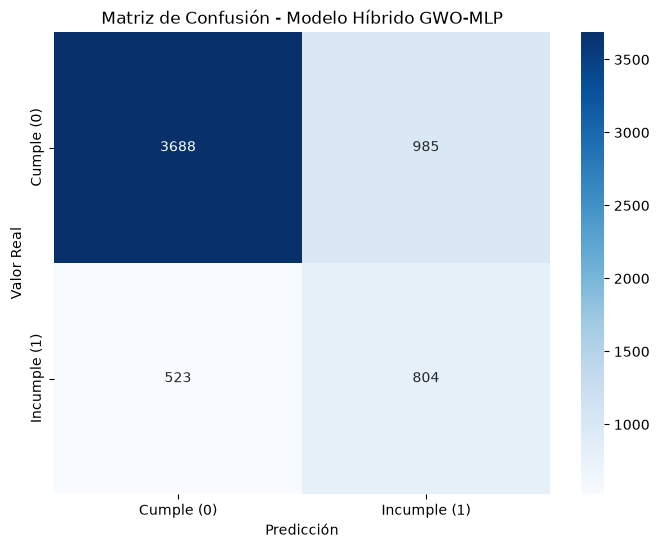


TP: 804 | FP: 985
FN: 523 | TN: 3688


In [ ]:
# Evaluar en test set
print("\n📊 EVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP")
print("="*60)

y_pred_prob = final_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*60)

# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cumple (0)', 'Incumple (1)'],
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title('Matriz de Confusión - Modelo Híbrido GWO-MLP')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

print(f"\nTP: {cm[1,1]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]} | TN: {cm[0,0]}")

### Visualización de Convergencia GWO

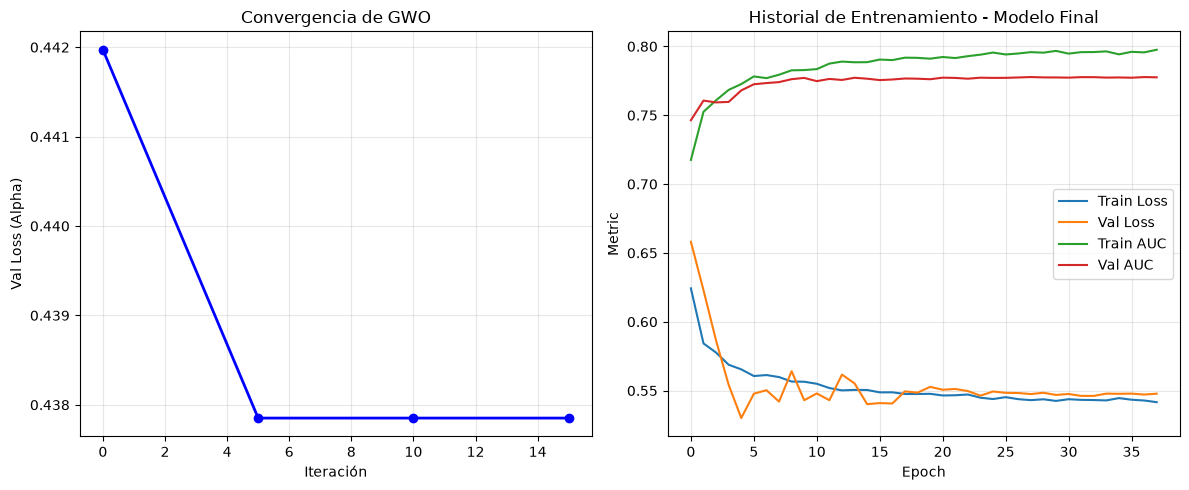

In [ ]:
# Visualizar convergencia de GWO
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
iterations = [h['iteration'] for h in gwo.history]
scores = [h['alpha_score'] for h in gwo.history]
plt.plot(iterations, scores, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Iteración')
plt.ylabel('Val Loss (Alpha)')
plt.title('Convergencia de GWO')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Historial de Entrenamiento - Modelo Final')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()